In [1]:
import matplotlib.pyplot as plt
import ipympl
print("ipympl is installed")

ipympl is installed


In [2]:
import matplotlib.pyplot as plt
import re
import dpsimpy
import numpy as np
# %matplotlib widget

In [12]:
import pandas as pd
df1 = pd.read_csv('/logs/CreteValleyMinActiveLoad copy.csv', skipinitialspace=True)
df2 = pd.read_csv('/logs/CreteValley_minActiveOnly.csv', skipinitialspace=True)
df1.info()
df2.info()
# Filter columns: keep only those that do NOT contain 'lne' or 'trf'
filtered_cols = df1.columns[~df1.columns.str.contains('lne|trf|MV', case=False, regex=True)]
filtered_cols2 = df2.columns[~df2.columns.str.contains('lne|trf|MV', case=False, regex=True)]
# Create a new DataFrame with only the filtered columns
df1_filtered = df1[filtered_cols]
df2_filtered = df2[filtered_cols2]
# Optional: check which columns were kept
#print(df1_filtered.columns.tolist())
#print(df2_filtered.columns.tolist())

df1_filtered.info()
df2_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Columns: 1117 entries, time to trf_91931_291931_A1_Q_1
dtypes: float64(1117)
memory usage: 12.3 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Columns: 157 entries, time to 94578 2LINO-S5.V.re
dtypes: float64(157)
memory usage: 1.7 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Columns: 141 entries, time to 94631 DAMASTA_V.re
dtypes: float64(141)
memory usage: 1.6 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Columns: 115 entries, time to 94578 2LINO-S5.V.re
dtypes: float64(115)
memory usage: 1.3 MB


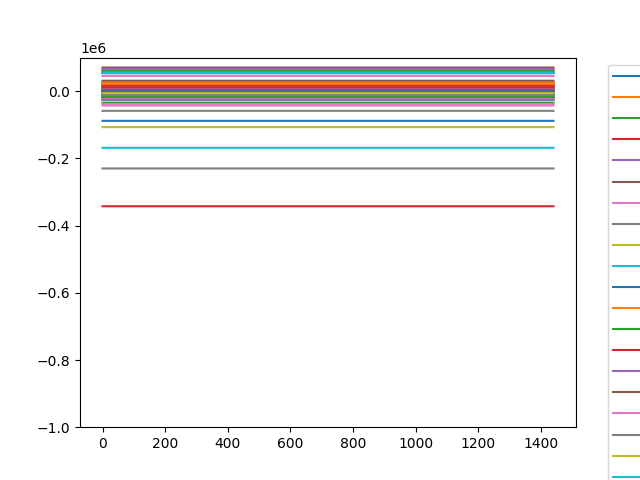

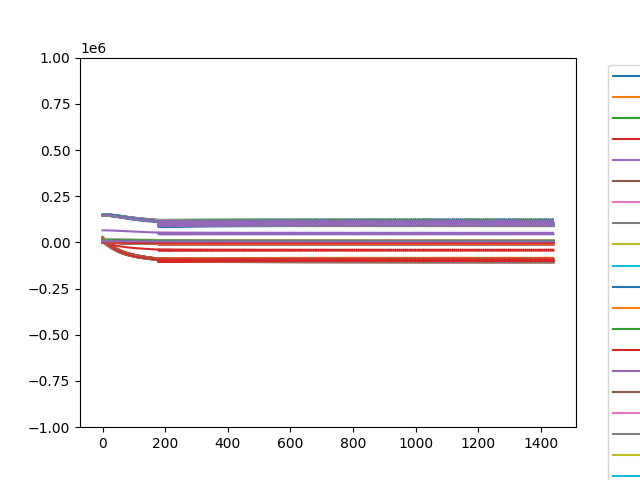

In [14]:
import matplotlib.pyplot as plt
import numpy as np


df1_filtered.plot()
plt.ylim(-1000000, 100000)   # optional — limit y-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside
plt.show()


df2_filtered.plot()
plt.ylim(-1000000, 1000000)   # optional — limit y-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside
plt.show()

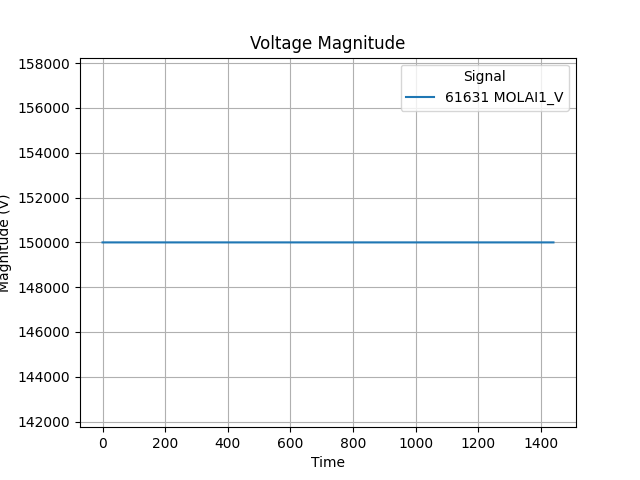

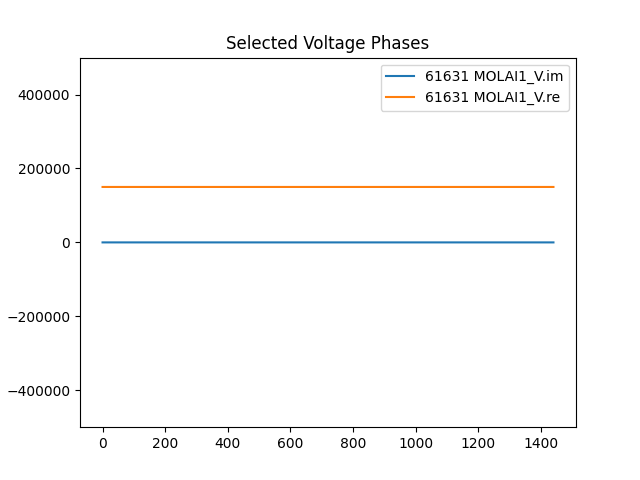

In [10]:
import matplotlib.pyplot as plt

# List of columns you want
cols_to_plot = [
    '61631 MOLAI1_V.im', 
    '61631 MOLAI1_V.re'
    #'202101 SOL_POW_ MV_V.im'
    #'202101 SOL_POW_ MV_V.re'
    #'2101 SOL_POW_HV_V.im',
    #'2101 SOL_POW_HV_V.re',
    #'2102 SOL_POW_T1_V.im',
    #'2102 SOL_POW_T1_V.re',
    #'2103 SOL_POW_T2_V.im',
    #'2103 SOL_POW_T2_V.re'
]

# Filter the DataFrame to only include these columns (if they exist)
df_selected = df1_filtered[[col for col in cols_to_plot if col in df1_filtered.columns]]
# Extract base names (remove the .re/.im suffix)
base_signals = sorted(set(col.rsplit('.', 1)[0] for col in cols_to_plot))

magnitudes = {}

# Compute magnitudes for each base signal
for base in base_signals:
    re_col = f"{base}.re"
    im_col = f"{base}.im"
    if re_col in df1_filtered.columns and im_col in df1_filtered.columns:
        magnitudes[base] = np.sqrt(df1_filtered[re_col]**2 + df1_filtered[im_col]**2)

# Convert to DataFrame for plotting
df_magnitude = pd.DataFrame(magnitudes, index=df1_filtered.index)

# Plot
df_magnitude.plot()
plt.title('Voltage Magnitude')
plt.ylabel('Magnitude (V)')
plt.xlabel('Time')
plt.legend(title='Signal')
plt.grid(True)
plt.show()


# Plot them
df_selected.plot()
plt.ylim(-0.5e6, 0.5e6)
plt.legend()
plt.title('Selected Voltage Phases')
plt.show()

In [11]:
import matplotlib.pyplot as plt

# List of columns you want
cols_to_plot = [
    '61631 MOLAI1_V.im', 
    '61631 MOLAI1_V.re', 
    '91131 PRETORIA_V.im', 
    '91131 PRETORIA_V.re', 
    #'91231 AG.VARV_V.im', 
    #'91231 AG.VARV_V.re'
    #'202101 SOL_POW_ MV_V.im'
    #'202101 SOL_POW_ MV_V.re'
    #'2101 SOL_POW_HV_V.im',
    #'2101 SOL_POW_HV_V.re',
    #'2102 SOL_POW_T1_V.im',
    #'2102 SOL_POW_T1_V.re',
    #'2103 SOL_POW_T2_V.im',
    #'2103 SOL_POW_T2_V.re'
]

# Filter the DataFrame to only include these columns (if they exist)
df_selected = df2_filtered[[col for col in cols_to_plot if col in df2_filtered.columns]]

# Extract base names (remove the .re/.im suffix)
base_signals = sorted(set(col.rsplit('.', 1)[0] for col in cols_to_plot))

magnitudes = {}

# Compute magnitudes for each base signal
for base in base_signals:
    re_col = f"{base}.re"
    im_col = f"{base}.im"
    if re_col in df2_filtered.columns and im_col in df2_filtered.columns:
        magnitudes[base] = np.sqrt(df2_filtered[re_col]**2 + df2_filtered[im_col]**2)

# Convert to DataFrame for plotting
df_magnitude = pd.DataFrame(magnitudes, index=df2_filtered.index)

# Plot
df_magnitude.plot()
plt.title('Voltage Magnitude')
plt.ylabel('Magnitude (V)')
plt.xlabel('Time')
plt.legend(title='Signal')
plt.grid(True)
plt.show()

# Plot them
df_selected.plot()
plt.ylim(-0.5e6, 0.5e6)
plt.legend()
plt.title('Selected Voltage Phases')
plt.show()

TypeError: no numeric data to plot

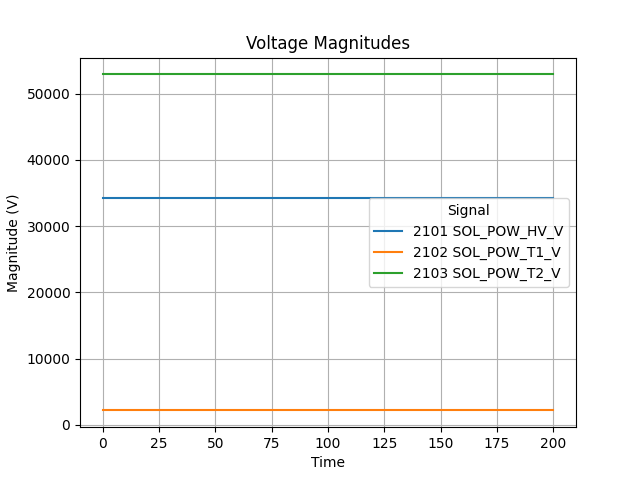

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# List all columns (can include both .re and .im for multiple signals)
cols_to_plot = [
    '61631 MOLAI1.V.im', 
    '61631 MOLAI1.V.re',
    '2101 SOL_POW_HV_V.im',
    '2101 SOL_POW_HV_V.re',
    '2102 SOL_POW_T1_V.im',
    '2102 SOL_POW_T1_V.re',
    '2103 SOL_POW_T2_V.im',
    '2103 SOL_POW_T2_V.re'
]

# Make sure columns exist in your DataFrame
existing_cols = [c for c in cols_to_plot if c in df1_filtered.columns]

# Extract unique base signal names (everything before the last dot)
base_signals = sorted(set(col.rsplit('.', 1)[0] for col in existing_cols))

magnitudes = {}

# Compute magnitude for each base signal (if both re/im exist)
for base in base_signals:
    re_col = f"{base}.re"
    im_col = f"{base}.im"
    if re_col in df1_filtered.columns and im_col in df1_filtered.columns:
        magnitudes[base] = np.sqrt(df1_filtered[re_col]**2 + df1_filtered[im_col]**2)

# Convert to DataFrame for plotting
df_magnitude = pd.DataFrame(magnitudes, index=df1_filtered.index)

# Plot
df_magnitude.plot()
plt.title('Voltage Magnitudes')
plt.ylabel('Magnitude (V)')
plt.xlabel('Time')
plt.legend(title='Signal')
plt.grid(True)
plt.show()
